# Pertemuan 10 — Algoritma Klasifikasi (Bagian 2): Customer Churn

**Nama Lengkap :** Novan Frido Saputro  
**NIM           :** 240401010119  
**Kelas         :** IF403  
**Program Studi :** Informatika  
**Mata Kuliah   :** Data Science  


In [1]:
# Langkah 1: Muat dan Eksplorasi Data
# Sebelum run: upload file 'WA_Fn-UseC_-Telco-Customer-Churn.csv' via
# Files (ikon folder sidebar kiri Colab) → Upload → rename jadi telco_churn.csv
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Shape:', df.shape)
print('\nTipe data:')
print(df.dtypes)
print('\nProporsi kelas Churn:')
print(df['Churn'].value_counts(normalize=True).round(3))
print('\n5 baris pertama:')
print(df.head())


Shape: (7043, 21)

Tipe data:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Proporsi kelas Churn:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64

5 baris pertama:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male 

In [2]:
# Cek missing values
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# TotalCharges kadang bertipe object, konversi ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print('\nMissing values setelah handling:')
print(df.isnull().sum().sum(), 'missing tersisa')

Missing values:
Series([], dtype: int64)

Missing values setelah handling:
0 missing tersisa


In [3]:
# Langkah 2: Preprocessing
from sklearn.model_selection import train_test_split

# Drop kolom ID yang tidak relevan
df = df.drop('customerID', axis=1)

# Encoding target: Yes=1, No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encoding fitur kategorikal dengan get_dummies
df = pd.get_dummies(df, drop_first=True, dtype=int)

print('Kolom setelah encoding:', df.shape[1], 'kolom')
print('\nSample kolom:', df.columns.tolist()[:10])

# Pisahkan fitur dan target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split stratified
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'\nTrain: {X_tr.shape[0]} baris')
print(f'Test : {X_te.shape[0]} baris')
print('\nProporsi churn di train:', y_tr.value_counts(normalize=True).round(3).to_dict())
print('Proporsi churn di test :', y_te.value_counts(normalize=True).round(3).to_dict())

Kolom setelah encoding: 31 kolom

Sample kolom: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']

Train: 5634 baris
Test : 1409 baris

Proporsi churn di train: {0: 0.735, 1: 0.265}
Proporsi churn di test : {0: 0.735, 1: 0.265}


In [4]:
# Langkah 3: Latih Model — Random Forest dengan class_weight='balanced'
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_tr, y_tr)

print('Model selesai dilatih!')
print(f'Jumlah pohon : {rf.n_estimators}')
print(f'Jumlah fitur : {rf.n_features_in_}')

Model selesai dilatih!
Jumlah pohon : 300
Jumlah fitur : 30


In [5]:
# Langkah 4: Evaluasi
from sklearn.metrics import classification_report, roc_auc_score

y_pred  = rf.predict(X_te)
y_proba = rf.predict_proba(X_te)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))

roc_auc = roc_auc_score(y_te, y_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8246


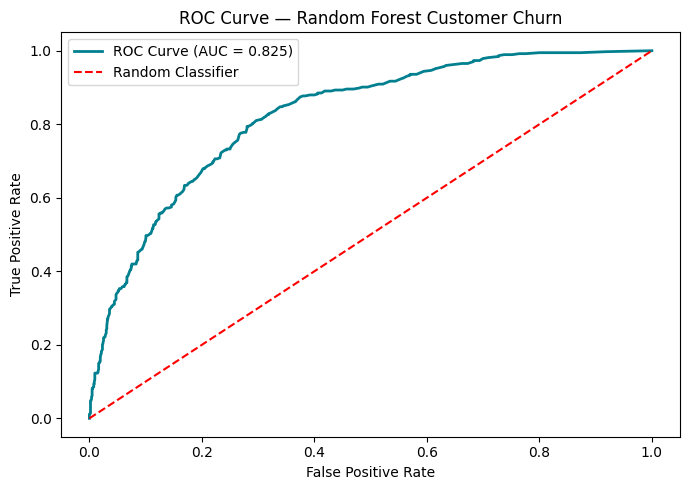

In [6]:
# Visualisasi ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_te, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#028090', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest Customer Churn')
plt.legend()
plt.tight_layout()
plt.show()

10 Pelanggan dengan Risiko Churn Tertinggi:
 Probabilitas_Churn  Prediksi  Aktual
           1.000000         1       1
           0.993333         1       1
           0.990000         1       1
           0.990000         1       1
           0.986667         1       1
           0.986667         1       0
           0.970000         1       0
           0.963333         1       1
           0.960000         1       1
           0.950000         1       1


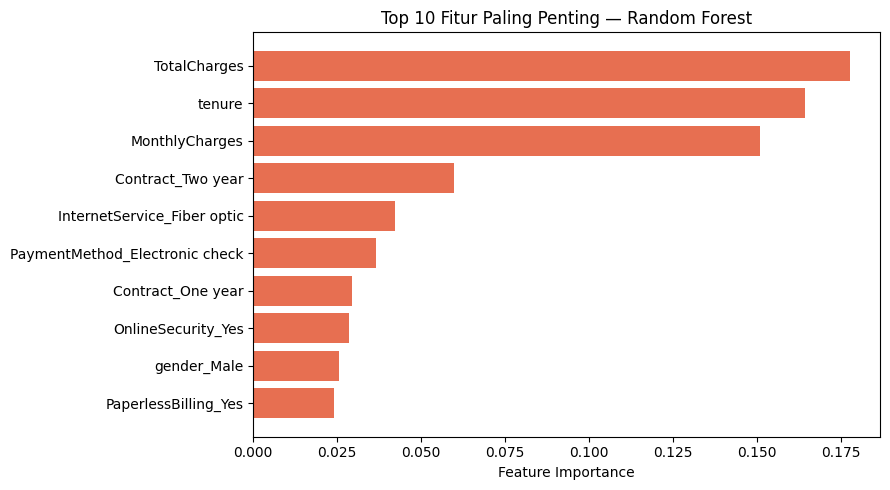

In [7]:
# Langkah 5: Prediksi Probabilitas Churn per Pelanggan
import pandas as pd

proba_df = pd.DataFrame({
    'Probabilitas_Churn': y_proba,
    'Prediksi'          : y_pred,
    'Aktual'            : y_te.values
}).sort_values('Probabilitas_Churn', ascending=False)

print('10 Pelanggan dengan Risiko Churn Tertinggi:')
print(proba_df.head(10).to_string(index=False))

# Feature importance
import numpy as np
feat_imp = pd.DataFrame({
    'Fitur'      : X.columns,
    'Importance' : rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(feat_imp['Fitur'], feat_imp['Importance'], color='#e76f51')
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 10 Fitur Paling Penting — Random Forest')
plt.tight_layout()
plt.show()

## Kesimpulan — Pertemuan 10: Customer Churn

Di pertemuan ini saya menggunakan Random Forest dengan `class_weight='balanced'` untuk menangani dataset yang imbalanced — sekitar 26.5% churn vs 73.5% tidak churn. Tanpa penanganan ini, model cenderung mengabaikan kelas minoritas (churn) karena jumlahnya lebih sedikit.

Dari feature importance, fitur seperti `tenure`, `MonthlyCharges`, dan `Contract` muncul sebagai yang paling berpengaruh. Ini cukup masuk akal — pelanggan baru dengan tagihan tinggi dan kontrak bulanan memang lebih berisiko untuk churn.

ROC-AUC menjadi metrik utama di sini karena lebih informatif dibanding Accuracy untuk dataset yang tidak seimbang. `predict_proba` juga berguna secara praktis karena memungkinkan tim bisnis untuk memprioritaskan pelanggan mana yang perlu ditangani lebih dulu berdasarkan probabilitas churn-nya.

Yang ingin saya coba selanjutnya adalah membandingkan Random Forest ini dengan XGBoost yang sering jadi pilihan utama untuk kasus klasifikasi tabular di kompetisi data science.
